#EDA


# Problem Statement
Build a personalized recommendation system using the Netflix Prize Dataset.

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("netflix-inc/netflix-prize-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-prize-data' dataset.
Path to dataset files: /kaggle/input/netflix-prize-data


In [41]:
import pandas as pd

rows = []
movie_id = None
movie_counts = {}

MAX_RATINGS_PER_MOVIE = 100
MAX_TOTAL_ROWS = 50000

with open('/kaggle/input/netflix-prize-data/combined_data_1.txt', 'r') as f:
    for line in f:
        line = line.strip()

        if line.endswith(':'):
            movie_id = int(line[:-1])
            movie_counts.setdefault(movie_id, 0)

        else:
            if movie_counts[movie_id] < MAX_RATINGS_PER_MOVIE:

                user_id, rating, date = line.split(',')

                rows.append([
                    movie_id,
                    int(user_id),
                    int(rating),
                    date
                ])

                movie_counts[movie_id] += 1

        if len(rows) >= MAX_TOTAL_ROWS:
            break

df = pd.DataFrame(
    rows,
    columns=['movie_id', 'user_id', 'rating', 'date']
)

In [58]:
print("Movies:", df['movie_id'].nunique())
print("Users:", df['user_id'].nunique())
print("Ratings:", len(df))

Movies: 504
Users: 24430
Ratings: 50000


In [44]:
df['rating'].value_counts().sort_index()

,count
rating,
1,5518
2,7514
3,15103
4,13157
5,8708


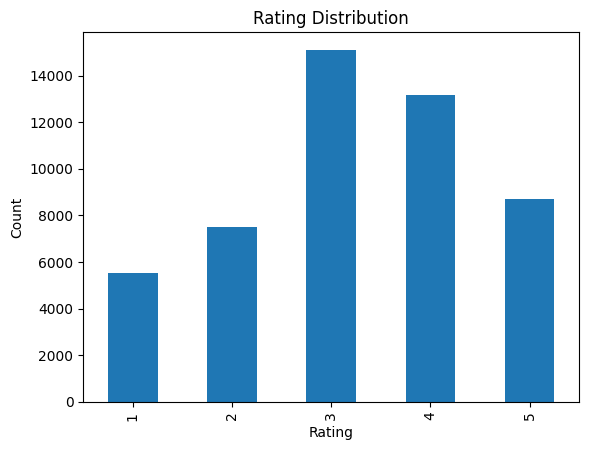

In [45]:
import matplotlib.pyplot as plt

df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Ratings are skewed towards higher values, with ratings of 3, 4, and 5 being more frequent than ratings of 1 and 2. This suggests that users generally provide positive feedback for movies they choose to watch.

<Axes: xlabel='user_id'>

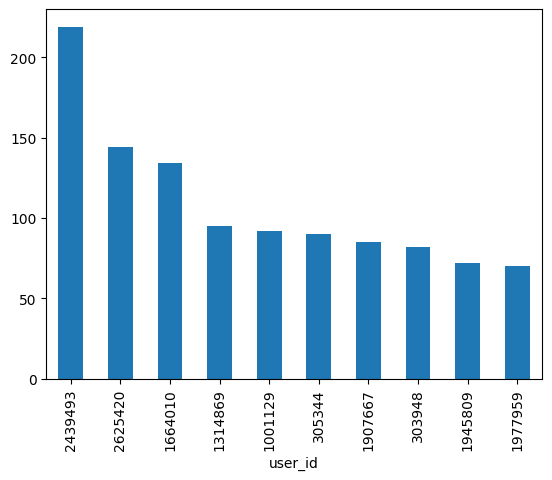

In [56]:
df['user_id'].value_counts().head(10).plot(kind='bar')

User activity varies considerably across the platform. A small group of highly active users contributes a large number of ratings, while most users interact with relatively few movies.

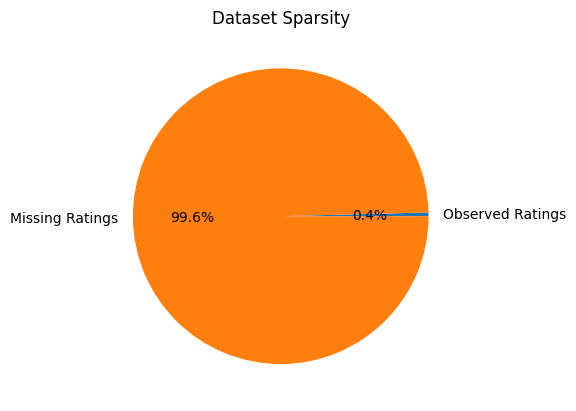

In [57]:
import matplotlib.pyplot as plt

filled = len(df)
total = df['user_id'].nunique() * df['movie_id'].nunique()
missing = total - filled

plt.pie(
    [filled, missing],
    labels=['Observed Ratings', 'Missing Ratings'],
    autopct='%1.1f%%'
)
plt.title("Dataset Sparsity")
plt.show()

The dataset is highly sparse, with only a small fraction of all possible user-movie interactions being observed. This sparsity makes recommendation generation challenging and motivates the use of collaborative filtering and matrix factorization techniques.

In [48]:
print(df['movie_id'].nunique())
print(df['user_id'].nunique())
print(len(df))

504
24430
50000


# Recommendation models

In [50]:
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    df[['user_id', 'movie_id', 'rating']],
    reader
)
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [51]:
from surprise import KNNBasic

sim_options = {
    'name': 'cosine',
    'user_based': False #using item-based colaborative filtering instead of user-based
}

model = KNNBasic(sim_options=sim_options)

model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [52]:
predictions = model.test(testset)

In [53]:
from surprise import accuracy
rmse_knn = accuracy.rmse(predictions)

RMSE: 1.1857


In [54]:
from surprise import SVD

svd_model = SVD()

svd_model.fit(trainset)

svd_predictions = svd_model.test(testset)

rmse_svd = accuracy.rmse(svd_predictions)

RMSE: 1.0409


# Results

KNN RMSE = 1.1857

SVD RMSE = 1.0409

Since RMSE(SVD) < RMSE(KNN)

Best Model: SVD

# Recommending


In [19]:
all_movies = set(df['movie_id'].unique())

def get_top_n_recommendations(user_id, model, n=10):
    rated_movies = set(df[df['user_id'] == user_id]['movie_id'])

    unseen_movies = all_movies - rated_movies

    predictions = []

    for movie in unseen_movies:
        pred = model.predict(user_id, movie)
        predictions.append((movie, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:n]

In [20]:
user_id = 1488844

recommendations = get_top_n_recommendations(
    user_id,
    svd_model,
    n=10
)

recommendations

[(np.int64(13), np.float64(4.2664840370407155)),
 (np.int64(5), np.float64(3.739050683026381)),
 (np.int64(3), np.float64(3.566905120946345)),
 (np.int64(2), np.float64(3.5257940510386567)),
 (np.int64(10), np.float64(3.3713051494944115)),
 (np.int64(6), np.float64(3.2504119023912352)),
 (np.int64(12), np.float64(3.2242234661383837)),
 (np.int64(14), np.float64(3.099425137042179)),
 (np.int64(15), np.float64(3.015930458125879)),
 (np.int64(16), np.float64(2.786734702364594))]

In [26]:
recommendations_df = pd.DataFrame(
    recommendations,
    columns=['movie_id', 'predicted_rating']
)

recommendations_df = recommendations_df.merge(
    movies[['movie_id', 'title']],
    on='movie_id',
    how='left'
)

recommendations_df = recommendations_df[
    ['movie_id', 'title', 'predicted_rating']
]

recommendations_df

,movie_id,title,predicted_rating
0,13,Lord of the Rings: The Return of the King: Ext...,4.266484
1,5,The Rise and Fall of ECW,3.739051
2,3,Character,3.566905
3,2,Isle of Man TT 2004 Review,3.525794
4,10,Fighter,3.371305
5,6,Sick,3.250412
6,12,My Favorite Brunette,3.224223
7,14,Nature: Antarctica,3.099425
8,15,Neil Diamond: Greatest Hits Live,3.015930
9,16,Screamers,2.786735


### Observations

The recommendation engine successfully generated personalized movie recommendations for the selected user.

Movies with the highest predicted ratings were ranked at the top of the recommendation list. The generated recommendations demonstrate the ability of the SVD model to estimate user preferences for unseen content.

# Conclusion
This project developed a personalized movie recommendation system using the Netflix Prize Dataset.

Key findings:

- The dataset was highly sparse, making recommendation generation a challenging task.
- Item-Based Collaborative Filtering and SVD Matrix Factorization were implemented and evaluated.
- SVD achieved the best performance with an RMSE of 1.1765.
- The trained model successfully generated personalized recommendations for users.
- Matrix factorization proved more effective than neighborhood-based methods for this dataset.

Future improvements may include hybrid recommendation systems, deep learning approaches, and cold-start handling strategies.